In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

In [2]:
#_____TASK 1_____

In [3]:
#SCENARIO A

"""
This is selection bias because only some users write reviews
Many users do not leave reviews, so the data is not complete
A fix is to ask all users for feedback inside the app
"""

#SCENARIO B

"""
This is survivorship bias because only successful startups are studied
Failed startups are not included, so the result is not fair
A fix is to also study startups that failed
"""

#SCENARIO C

"""
This is nonresponse bias because only 10% of people answered the survey
People who like health topics may answer more, so results look too positive
A fix is to get more responses or use random sampling
"""

#SCENARIO D

"""
This is selection bias because the data is mostly from big cities
It does not match small towns, so salaries may be wrong
A fix is to use local salary data for better results
"""

'\nThis is selection bias because the data is mostly from big cities\nIt does not match small towns, so salaries may be wrong\nA fix is to use local salary data for better results\n'

In [4]:
#_____TASK 2_____

Population Summary:
Mean Age: 40.02
Mean Income: 60675.27
Mean Satisfaction: 5.42

Region Proportions:
region
Urban       0.59927
Suburban    0.25075
Rural       0.14998
Name: proportion, dtype: float64


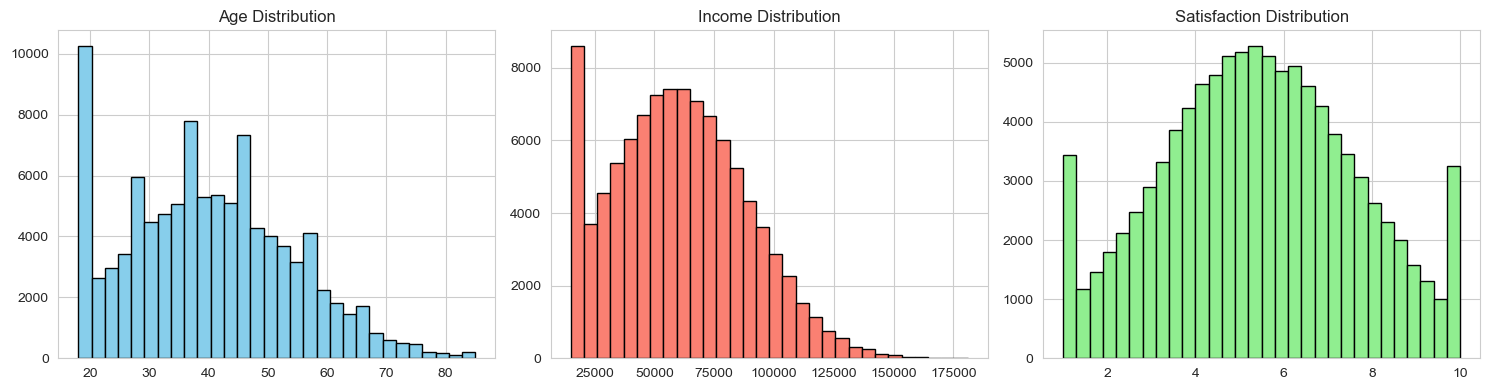

In [5]:
np.random.seed(42)
number_of_poplation = 100_000

age = np.random.normal(loc=40, scale=15, size=number_of_poplation)
age = np.clip(age, 18, 85).astype(int)

noise_income = np.random.normal(0, 20000, size=number_of_poplation)
income = 1500 * age + noise_income
income = np.clip(income, 15000, 250000)

noise_sat = np.random.normal(0, 2, size=number_of_poplation)
satisfaction = 3 + (income / 100000) * 4 + noise_sat
satisfaction = np.clip(satisfaction, 1, 10)

region = np.random.choice(
    ["Urban", "Suburban", "Rural"],
    size=number_of_poplation,
    p=[0.6, 0.25, 0.15]
)
    
population = pd.DataFrame({
    "age" : age,
    "income" : income,
    "satisfaction" : satisfaction,
    "region" : region
})

mean_age = population["age"].mean()
mean_income = population["income"].mean()
mean_satisfaction = population["satisfaction"].mean()
region_proportions = population["region"].value_counts(normalize=True)

print("Population Summary:")
print(f"Mean Age: {mean_age:.2f}")
print(f"Mean Income: {mean_income:.2f}")
print(f"Mean Satisfaction: {mean_satisfaction:.2f}")
print("\nRegion Proportions:")
print(region_proportions)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(population["age"], bins=30, color="skyblue", edgecolor="black")
axes[0].set_title("Age Distribution")

axes[1].hist(population["income"], bins=30, color="salmon", edgecolor="black")
axes[1].set_title("Income Distribution")

axes[2].hist(population["satisfaction"], bins=30, color="lightgreen", edgecolor="black")
axes[2].set_title("Satisfaction Distribution")

plt.tight_layout()
plt.show()

                Population           SRS    Urban Only   High Income
Age              40.020520     40.290000     39.700000     49.415000
Income        60675.269282  62424.166688  60492.592799  85726.042242
Satisfaction      5.424938      5.466802      5.572782      6.187295


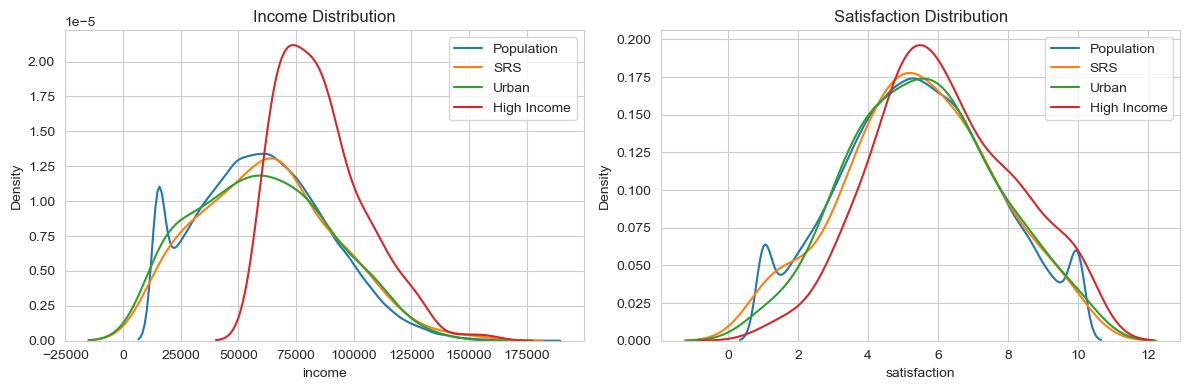

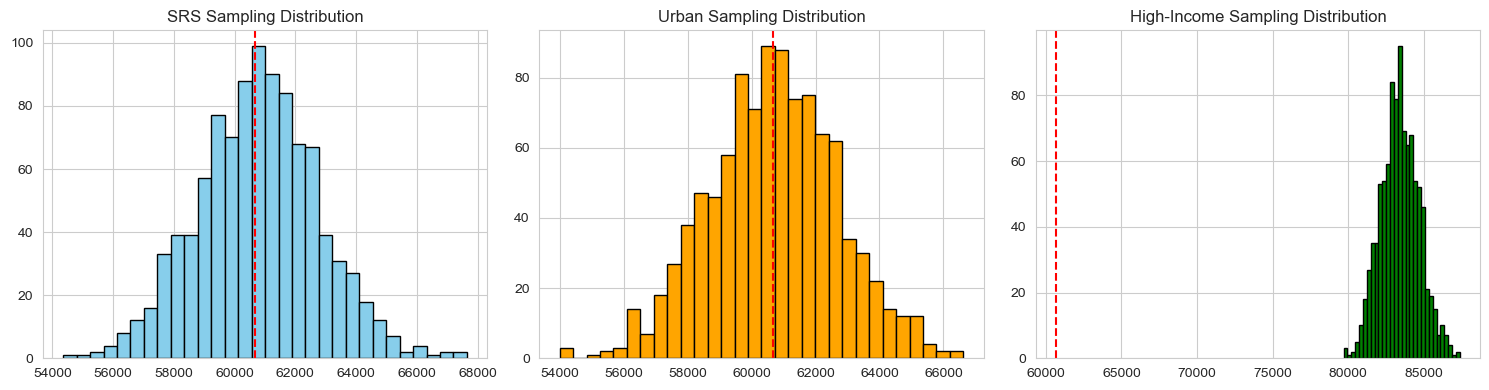

'\nThe urban-only and high-income sampling strategies produce biased estimates because their sampling distributions are shifted away from the true population mean\nBecause the peaks of their histograms do not line up with the population mean, unlike the simple random sample which is centered correctly.\n'

In [6]:
true_mean_age = population["age"].mean()
true_mean_income = population["income"].mean()
true_mean_satisfaction = population["satisfaction"].mean()

srs = population.sample(n=200, random_state=42)

urban_pop = population[population["region"] == "Urban"]
urban_sample = urban_pop.sample(n=200, random_state=42)

median_income = population["income"].median()
high_income_pop = population[population["income"] > median_income]
high_income_sample = high_income_pop.sample(n=200, random_state=42)

def summarize(df):
    return pd.Series({
        "Age": df["age"].mean(),
        "Income": df["income"].mean(),
        "Satisfaction": df["satisfaction"].mean()
    })

comparison = pd.DataFrame({
    "Population": summarize(population),
    "SRS": summarize(srs),
    "Urban Only": summarize(urban_sample),
    "High Income": summarize(high_income_sample)
})

print(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.kdeplot(population["income"], ax=axes[0], label="Population")
sns.kdeplot(srs["income"], ax=axes[0], label="SRS")
sns.kdeplot(urban_sample["income"], ax=axes[0], label="Urban")
sns.kdeplot(high_income_sample["income"], ax=axes[0], label="High Income")

axes[0].set_title("Income Distribution")
axes[0].legend()

sns.kdeplot(population["satisfaction"], ax=axes[1], label="Population")
sns.kdeplot(srs["satisfaction"], ax=axes[1], label="SRS")
sns.kdeplot(urban_sample["satisfaction"], ax=axes[1], label="Urban")
sns.kdeplot(high_income_sample["satisfaction"], ax=axes[1], label="High Income")

axes[1].set_title("Satisfaction Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

n_sim = 1000

srs_means = []
urban_means = []
high_income_means = []

for i in range(n_sim):
    s = population.sample(n=200)
    srs_means.append(s["income"].mean())

    s = urban_pop.sample(n=200)
    urban_means.append(s["income"].mean())

    s = high_income_pop.sample(n=200)
    high_income_means.append(s["income"].mean())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(srs_means, bins=30, color="skyblue", edgecolor="black")
axes[0].axvline(true_mean_income, color="red", linestyle="--")
axes[0].set_title("SRS Sampling Distribution")

axes[1].hist(urban_means, bins=30, color="orange", edgecolor="black")
axes[1].axvline(true_mean_income, color="red", linestyle="--")
axes[1].set_title("Urban Sampling Distribution")

axes[2].hist(high_income_means, bins=30, color="green", edgecolor="black")
axes[2].axvline(true_mean_income, color="red", linestyle="--")
axes[2].set_title("High-Income Sampling Distribution")

plt.tight_layout()
plt.show()

"""
The urban-only and high-income sampling strategies produce biased estimates because their sampling distributions are shifted away from the true population mean
Because the peaks of their histograms do not line up with the population mean, unlike the simple random sample which is centered correctly.
"""